# Machine Learning Project | Customer Churn Prediction

In [544]:
# Import libraries
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from  pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [545]:
csv_path = Path(r"C:\Users\glint\OneDrive\Documents\Ironhack lessons\Project_ML_Churn\Telco_Cusomer_Churn.csv")
print(csv_path)

C:\Users\glint\OneDrive\Documents\Ironhack lessons\Project_ML_Churn\Telco_Cusomer_Churn.csv


In [546]:
df = pd.read_csv(csv_path)

Data Description
- **CustomerID**: A unique ID that identifies each customer.
- **Gender**: The customer’s gender: Male, Female.
- **Senior Citizen**: Indicates if the customer is 65 or older: Yes, No.
- **Partner**: Indicates if the customer has a partner: Yes, No.
- **Dependents**: Indicates if the customer lives with any dependents: Yes, No.
- **Tenure in Months**: Total number of months the customer has been with the company.
- **Phone Service**: Indicates if the customer subscribes to home phone service: Yes, No.
- **Multiple Lines**: Indicates if the customer subscribes to multiple phone lines: Yes, No.
- **Internet Service**: Type of internet service: No, DSL, Fiber Optic, Cable.
- **Online Security**: Indicates subscription to online security service: Yes, No.
- **Online Backup**: Indicates subscription to online backup service: Yes, No.
- **Device Protection**: Indicates subscription to device protection plan: Yes, No.
- **Tech Support**: Indicates subscription to technical support service: Yes, No.
- **Streaming TV**: Indicates if the customer streams TV content: Yes, No.
- **Streaming Movies**: Indicates if the customer streams movies: Yes, No.
- **Contract**: Customer contract type: Month-to-Month, One Year, Two Year.
- **Paperless Billing**: Indicates if paperless billing is enabled: Yes, No.
- **Payment Method**: Payment type: Bank Withdrawal, Credit Card, Mailed Check.
- **Monthly Charge**: Customer’s monthly charge amount.
- **Total Charges**: Customer’s total charges to date.
- **Churn**: Yes = customer left the company, No = customer stayed.

In [547]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [548]:
df.shape

(7043, 21)

In [549]:
df.describe().T

# TotalCharges → can be very large >> Use Standard Scaler which is less sensitive to outliers.

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [550]:
# Check the data types
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [551]:
# Check for missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [552]:
# Convers "TotalCharges" into numeric format
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].dtypes

dtype('float64')

In [553]:
# Rename the Customer ID column
df.rename(columns={"customerID": "customerId"}, inplace=True)

In [554]:
# Tronsform the column names to lower case
import re

# columns
df.columns = [re.sub(r'(?<!^)(?=[A-Z])', '_', col).lower() for col in df.columns]

# string values
# df = df.apply(lambda x: x.str.lower() if x.dtype == "object" else x)

In [555]:
# Check for missing values
df.isnull().sum()

customer_id           0
gender                0
senior_citizen        0
partner               0
dependents            0
tenure                0
phone_service         0
multiple_lines        0
internet_service      0
online_security       0
online_backup         0
device_protection     0
tech_support          0
streaming_t_v         0
streaming_movies      0
contract              0
paperless_billing     0
payment_method        0
monthly_charges       0
total_charges        11
churn                 0
dtype: int64

In [556]:
# Dropping all missing values
df = df.dropna()

In [557]:
df.head(3)

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_t_v,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [558]:
df["customer_id"].nunique()

7032

Visualization customer behavior

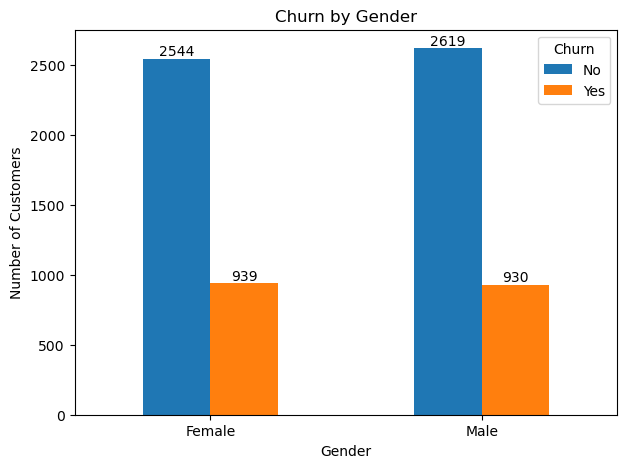

In [559]:
import matplotlib.pyplot as plt
import pandas as pd

# Crosstab
churn_gender = pd.crosstab(df["gender"], df["churn"])

# Plot
ax = churn_gender.plot(kind="bar", figsize=(7,5))

plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.legend(title="Churn")

plt.show()

In [560]:
gender_counts = (
    df["gender"]
      .value_counts(normalize=True) # Normalize return proportions (percentages) instead of raw counts.
      .mul(100) # mul put in 100 instead 0.1
      .round(2)
)
gender_counts

gender
Male      50.47
Female    49.53
Name: proportion, dtype: float64

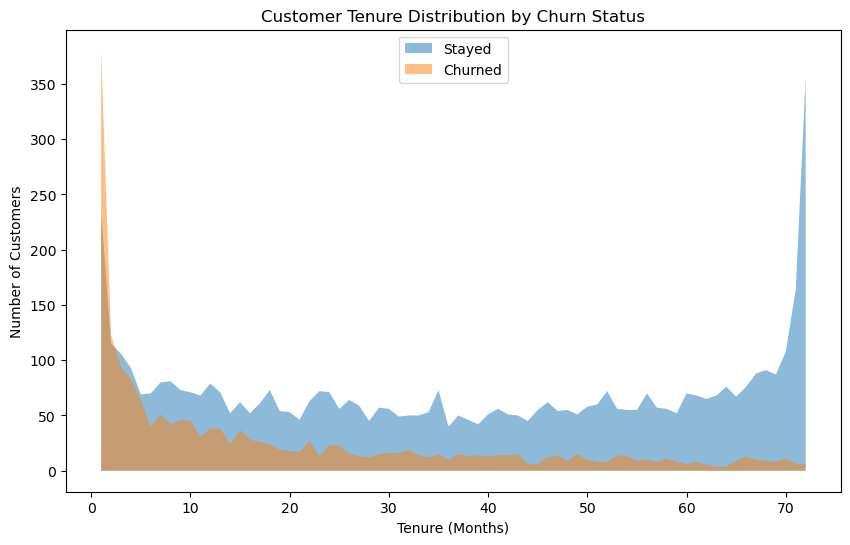

In [561]:
import matplotlib.pyplot as plt

# Count customers per tenure value
tenure_churn_no = df[df["churn"] == "No"]["tenure"].value_counts().sort_index()
tenure_churn_yes = df[df["churn"] == "Yes"]["tenure"].value_counts().sort_index()

# Align indexes (important)
all_index = sorted(set(tenure_churn_no.index).union(set(tenure_churn_yes.index)))

tenure_churn_no = tenure_churn_no.reindex(all_index, fill_value=0)
tenure_churn_yes = tenure_churn_yes.reindex(all_index, fill_value=0)

# Plot area chart
plt.figure(figsize=(10,6))

plt.fill_between(all_index, tenure_churn_no, alpha=0.5, label="Stayed")
plt.fill_between(all_index, tenure_churn_yes, alpha=0.5, label="Churned")

plt.title("Customer Tenure Distribution by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.legend()
plt.show()

C:\Users\glint\AppData\Local\Temp\ipykernel_23776\2741728711.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


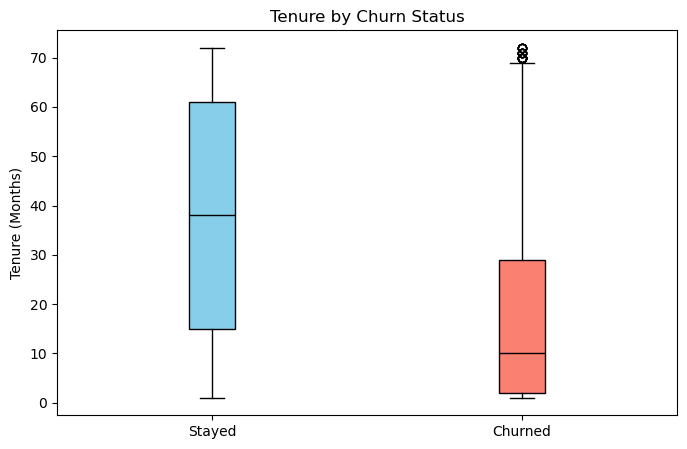

In [562]:
import matplotlib.pyplot as plt

# Split data
churn_yes = df[df["churn"] == "Yes"]["tenure"]
churn_no = df[df["churn"] == "No"]["tenure"]

plt.figure(figsize=(8,5))

box = plt.boxplot(
    [churn_no, churn_yes],
    labels=["Stayed", "Churned"],
    patch_artist=True
)

# Add colors
colors = ["skyblue", "salmon"]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

# Style whiskers and caps (optional but nicer)
for element in ["whiskers", "caps", "medians"]:
    plt.setp(box[element], color="black")

plt.title("Tenure by Churn Status")
plt.ylabel("Tenure (Months)")

plt.show()

C:\Users\glint\AppData\Local\Temp\ipykernel_23776\262112177.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


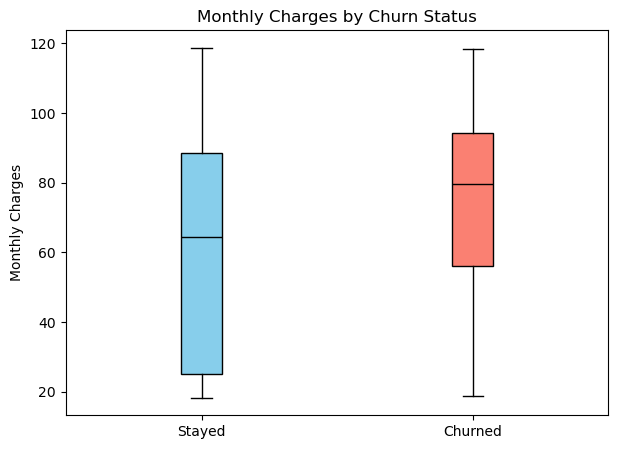

In [563]:
import matplotlib.pyplot as plt

# Split data
charges_yes = df[df["churn"] == "Yes"]["monthly_charges"]
charges_no = df[df["churn"] == "No"]["monthly_charges"]

plt.figure(figsize=(7,5))

# Create colored boxplot
box = plt.boxplot(
    [charges_no, charges_yes],
    labels=["Stayed", "Churned"],
    patch_artist=True
)

# Colors
colors = ["skyblue", "salmon"]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

# Style lines
for element in ["whiskers", "caps", "medians"]:
    plt.setp(box[element], color="black")

# Titles
plt.title("Monthly Charges by Churn Status")
plt.ylabel("Monthly Charges")

plt.show()

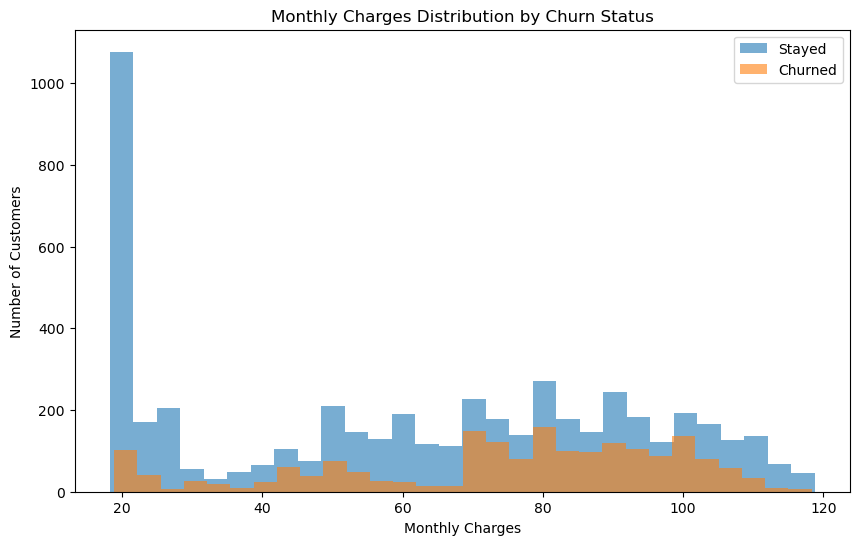

In [564]:
import matplotlib.pyplot as plt

charges_yes = df[df["churn"] == "Yes"]["monthly_charges"]
charges_no = df[df["churn"] == "No"]["monthly_charges"]

plt.figure(figsize=(10,6))

plt.hist(charges_no, bins=30, alpha=0.6, label="Stayed")
plt.hist(charges_yes, bins=30, alpha=0.6, label="Churned")

plt.title("Monthly Charges Distribution by Churn Status")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.legend()
plt.show()

C:\Users\glint\AppData\Local\Temp\ipykernel_23776\2177060561.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


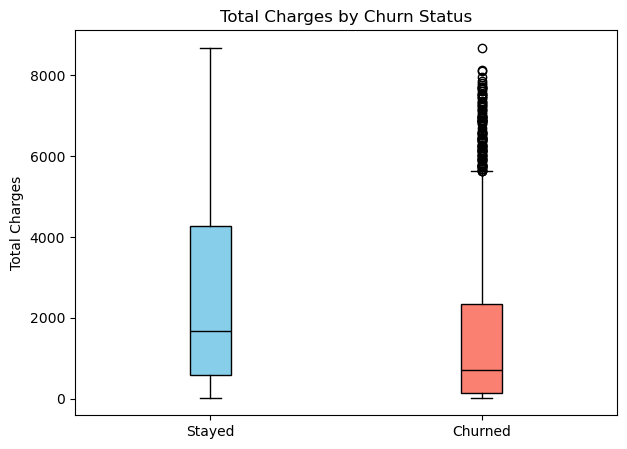

In [565]:
import matplotlib.pyplot as plt

# Split data
charges_yes = df[df["churn"] == "Yes"]["total_charges"]
charges_no = df[df["churn"] == "No"]["total_charges"]

plt.figure(figsize=(7,5))

# Create colored boxplot
box = plt.boxplot(
    [charges_no, charges_yes],
    labels=["Stayed", "Churned"],
    patch_artist=True
)

# Colors
colors = ["skyblue", "salmon"]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

# Style lines
for element in ["whiskers", "caps", "medians"]:
    plt.setp(box[element], color="black")

# Titles
plt.title("Total Charges by Churn Status")
plt.ylabel("Total Charges")

plt.show()

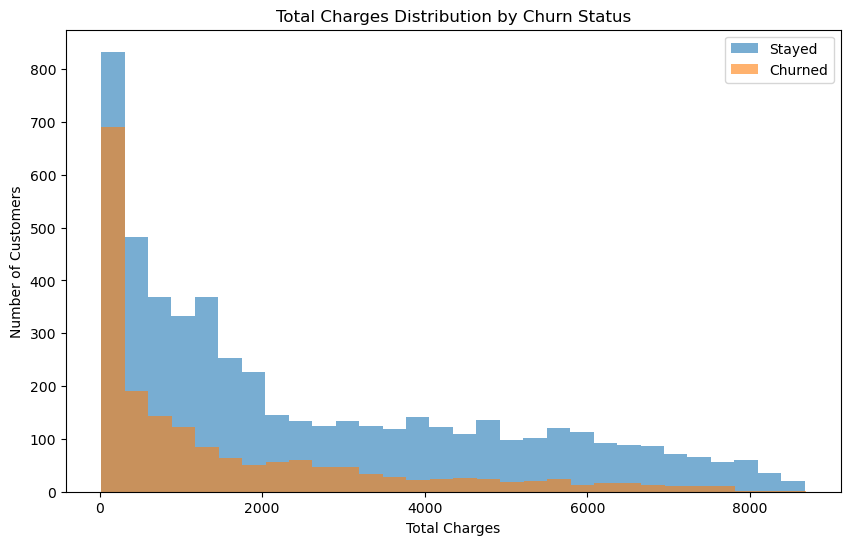

In [566]:
total_charges_yes = df[df["churn"] == "Yes"]["total_charges"]
total_charges_no = df[df["churn"] == "No"]["total_charges"]

plt.figure(figsize=(10,6))

plt.hist(charges_no, bins=30, alpha=0.6, label="Stayed")
plt.hist(charges_yes, bins=30, alpha=0.6, label="Churned")

plt.title("Total Charges Distribution by Churn Status")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.legend()
plt.show()

In [567]:
df.shape

(7032, 21)

In [568]:
#Check the duplicates
df.duplicated().sum()

np.int64(0)

In [569]:
df_clean = df.drop(columns=["customer_id"])

## Feature Selection

Encode Categorical variables

In [570]:
# Features
X = df_clean.drop(columns=["churn"])

# One-hot encode features
X = pd.get_dummies(X, drop_first=True)

In [571]:
# Target
y = df_clean["churn"].map({"Yes": 1, "No": 0})

In [572]:
# Numeric safety check
X = X.apply(pd.to_numeric, errors="raise")

Split the data into Train and Test

In [573]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0
)

In [574]:
# Build correlation dataset
df_corr = X.copy()
df_corr["churn"] = y

# Compute correlation
corr = np.abs(df_corr.corr())

Check Correlation between Features and Target

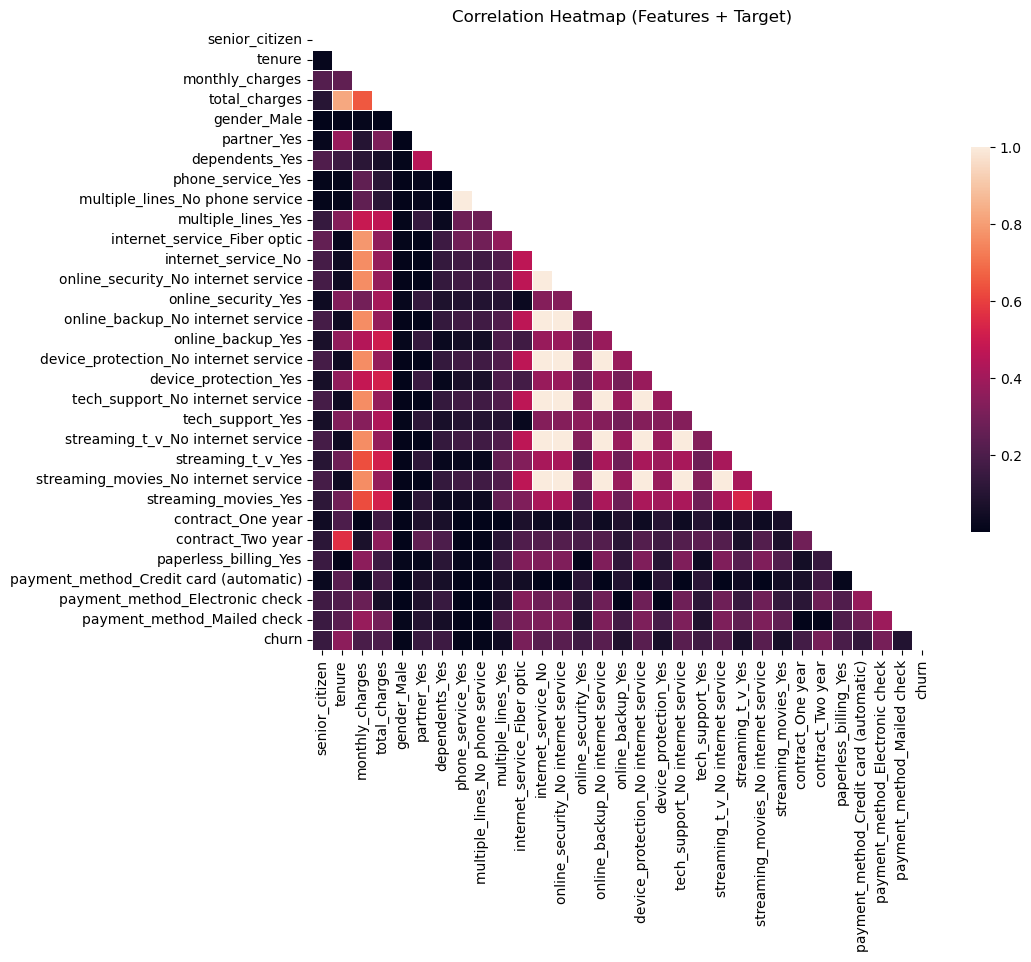

In [575]:
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

plt.figure(figsize=(10,10))

sns.heatmap(
    corr,
    mask=mask,
    vmax=1,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .5},
    annot=False
)

plt.title("Correlation Heatmap (Features + Target)")
plt.show()

Feature Selection

In [576]:
corr_target = df_corr.corr()["churn"].sort_values(ascending=False)
print(corr_target)

churn                                     1.000000
internet_service_Fiber optic              0.307463
payment_method_Electronic check           0.301455
monthly_charges                           0.192858
paperless_billing_Yes                     0.191454
senior_citizen                            0.150541
streaming_t_v_Yes                         0.063254
streaming_movies_Yes                      0.060860
multiple_lines_Yes                        0.040033
phone_service_Yes                         0.011691
gender_Male                              -0.008545
multiple_lines_No phone service          -0.011691
device_protection_Yes                    -0.066193
online_backup_Yes                        -0.082307
payment_method_Mailed check              -0.090773
payment_method_Credit card (automatic)   -0.134687
partner_Yes                              -0.149982
dependents_Yes                           -0.163128
tech_support_Yes                         -0.164716
online_security_Yes            

Train / test split

In [577]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Normalization of Data

In [578]:
# 1. Import the scaler >> This imports a tool that standardizes the data.

# Creating a “scaling machine” that will learn:
# mean of each column
# standard deviation of each column
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train KNN model

In [579]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Predictions

In [580]:
# Make predictions
y_pred = knn.predict(X_test)

Evaluation Metric: F1-score

Because churn prediction is usually:

- slightly imbalanced
- business-critical
- sensitive to false negatives

In [581]:
# Recal evaluation metric
recall_score(y_test, y_pred)

0.3582887700534759

In [582]:
# F1 score evaluation metric
from sklearn.metrics import f1_score

f1_score(y_test, y_pred)

0.46935201401050786

In [583]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7846481876332623
[[970  63]
 [240 134]]
              precision    recall  f1-score   support

           0       0.80      0.94      0.86      1033
           1       0.68      0.36      0.47       374

    accuracy                           0.78      1407
   macro avg       0.74      0.65      0.67      1407
weighted avg       0.77      0.78      0.76      1407



In [584]:
for k in range(1, 20):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    print(k, model.score(X_test, y_test))

1 0.7221037668798863
2 0.757640369580668
3 0.7540867093105899
4 0.7711442786069652
5 0.7690120824449183
6 0.7761194029850746
7 0.7718550106609808
8 0.7867803837953091
9 0.7839374555792467
10 0.7846481876332623
11 0.7839374555792467
12 0.7846481876332623
13 0.7938877043354655
14 0.7818052594171997
15 0.783226723525231
16 0.7846481876332623
17 0.7853589196872779
18 0.7846481876332623
19 0.7882018479033405


## Linear Regression

In [585]:
lin_reg = LinearRegression()

In [586]:
lin_reg.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Evaluate model's performance

In [587]:
pred = lin_reg.predict(X_test_scaled)

print("MAE", mean_absolute_error(y_test, pred))

rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE", rmse)

print("R2 score", lin_reg.score(X_test_scaled, y_test))

MAE 0.3032575867284398
RMSE 0.38201507951631136
R2 score 0.25221407931758144


In [588]:
# These are the model coefficients, and they show: how each feature influences churn prediction.
lin_reg_coef = {feature: coef for feature, coef in zip(X.columns, lin_reg.coef_)}
lin_reg_coef

# >>internet_service_Fiber optic = +0.136
# This is the strongest churn-increasing feature: Customers using fiber optic internet are more likely to churn.

{'senior_citizen': np.float64(0.020067596766336442),
 'tenure': np.float64(-0.04634482589108087),
 'monthly_charges': np.float64(-0.11087266936891127),
 'total_charges': np.float64(-0.10298880109819718),
 'gender_Male': np.float64(-0.0018454788957221503),
 'partner_Yes': np.float64(0.003521651947724193),
 'dependents_Yes': np.float64(-0.013028916043127408),
 'phone_service_Yes': np.float64(0.006339720101666873),
 'multiple_lines_No phone service': np.float64(-0.006339720101667039),
 'multiple_lines_Yes': np.float64(0.03379199899693049),
 'internet_service_Fiber optic': np.float64(0.13576316116282966),
 'internet_service_No': np.float64(-0.013793815902627965),
 'online_security_No internet service': np.float64(-0.013793815902627798),
 'online_security_Yes': np.float64(-0.01682988728578959),
 'online_backup_No internet service': np.float64(-0.013793815902627687),
 'online_backup_Yes': np.float64(0.0036025523580675805),
 'device_protection_No internet service': np.float64(-0.0137938159026

## Decision Tree

In [589]:
tree = DecisionTreeRegressor(max_depth=10)

In [590]:
tree.fit(X_train_scaled, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [591]:
X_train_scaled

array([[-0.43758982,  0.43467403, -0.51862031, ..., -0.52764485,
        -0.71475753, -0.54742719],
       [-0.43758982, -1.19565249, -0.3744434 , ...,  1.89521417,
        -0.71475753, -0.54742719],
       [-0.43758982,  0.92377199,  0.43261589, ..., -0.52764485,
         1.39907586, -0.54742719],
       ...,
       [-0.43758982, -0.95110351,  0.5453059 , ..., -0.52764485,
         1.39907586, -0.54742719],
       [-0.43758982,  0.71998118, -1.48974299, ..., -0.52764485,
        -0.71475753, -0.54742719],
       [ 2.28524509, -0.50276372,  0.29672501, ..., -0.52764485,
         1.39907586, -0.54742719]], shape=(5625, 30))

In [592]:
y_test

2481    0
6784    0
6125    1
3052    0
4099    0
       ..
1733    0
5250    0
5465    0
5851    0
3984    0
Name: churn, Length: 1407, dtype: int64

In [593]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

pred = tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

# MAE ≈ 0.48 means:
# model is only slightly better than random guessing
# but this is NOT interpretable for churn business decisions

Accuracy: 0.7249466950959488
[[825 208]
 [179 195]]
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1033
           1       0.48      0.52      0.50       374

    accuracy                           0.72      1407
   macro avg       0.65      0.66      0.66      1407
weighted avg       0.73      0.72      0.73      1407



# >> Next steps
1. Check how to interprete the results
2. Which evaluation metric to use
3. Check using heatmap which features to keep